In [48]:
pip install pystan

In [49]:
pip install prophet

In [50]:
pip install prophet

In [51]:
import pandas as pd
import prophet
import matplotlib.pyplot as plt
%matplotlib inline

In [52]:
df=pd.read_csv('airline_passengers.csv')

In [53]:
df.head()

,Month,Thousands of Passengers
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0


In [54]:
df.tail()

,Month,Thousands of Passengers
140,1960-09,508.0
141,1960-10,461.0
142,1960-11,390.0
143,1960-12,432.0
144,International airline passengers: monthly tota...,NaN


<Axes: >

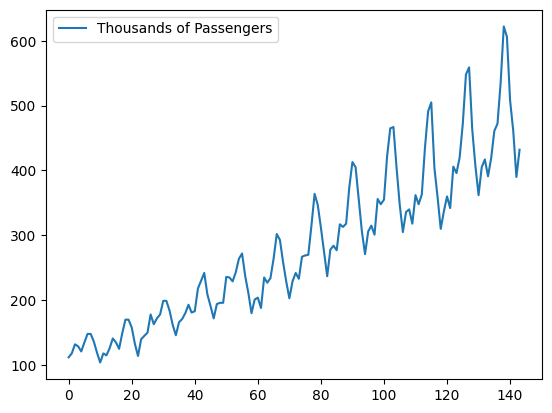

In [55]:
df.plot()

In [56]:
df.columns=['da','y']
df.head()

,da,y
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0


In [57]:
df.drop(144,axis=0,inplace=True)

In [58]:
df.tail()

,da,y
139,1960-08,606.0
140,1960-09,508.0
141,1960-10,461.0
142,1960-11,390.0
143,1960-12,432.0


In [59]:
df['da']=pd.to_datetime(df['da'])
df.head()

,da,y
0,1949-01-01,112.0
1,1949-02-01,118.0
2,1949-03-01,132.0
3,1949-04-01,129.0
4,1949-05-01,121.0


In [60]:
from prophet import Prophet

In [61]:
dir(prophet)

['Path',
 'Prophet',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 'about',
 'diagnostics',
 'f',
 'forecaster',
 'here',
 'make_holidays',
 'models',
 'plot']

In [62]:
model=Prophet()

In [63]:
df.columns

Index(['da', 'y'], dtype='object')

In [64]:
df.rename(columns={'da': 'ds'}, inplace=True)
model.fit(df)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [65]:
#create date future of 365
future_dates=model.make_future_dataframe(periods=365)
future_dates.tail()

,ds
504,1961-11-27
505,1961-11-28
506,1961-11-29
507,1961-11-30
508,1961-12-01


In [66]:
pred=model.predict(future_dates)

In [67]:
pred.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1949-01-01,107.406531,56.563506,114.800649,107.406531,107.406531,-21.387397,-21.387397,-21.387397,-21.387397,-21.387397,-21.387397,0.0,0.0,0.0,86.019134
1,1949-02-01,109.550753,50.035188,108.996779,109.550753,109.550753,-30.055287,-30.055287,-30.055287,-30.055287,-30.055287,-30.055287,0.0,0.0,0.0,79.495466
2,1949-03-01,111.487469,80.098568,139.797409,111.487469,111.487469,-0.461745,-0.461745,-0.461745,-0.461745,-0.461745,-0.461745,0.0,0.0,0.0,111.025724
3,1949-04-01,113.631691,81.102341,137.180236,113.631691,113.631691,-4.912527,-4.912527,-4.912527,-4.912527,-4.912527,-4.912527,0.0,0.0,0.0,108.719164
4,1949-05-01,115.706744,82.008607,138.907255,115.706744,115.706744,-3.611280,-3.611280,-3.611280,-3.611280,-3.611280,-3.611280,0.0,0.0,0.0,112.095464


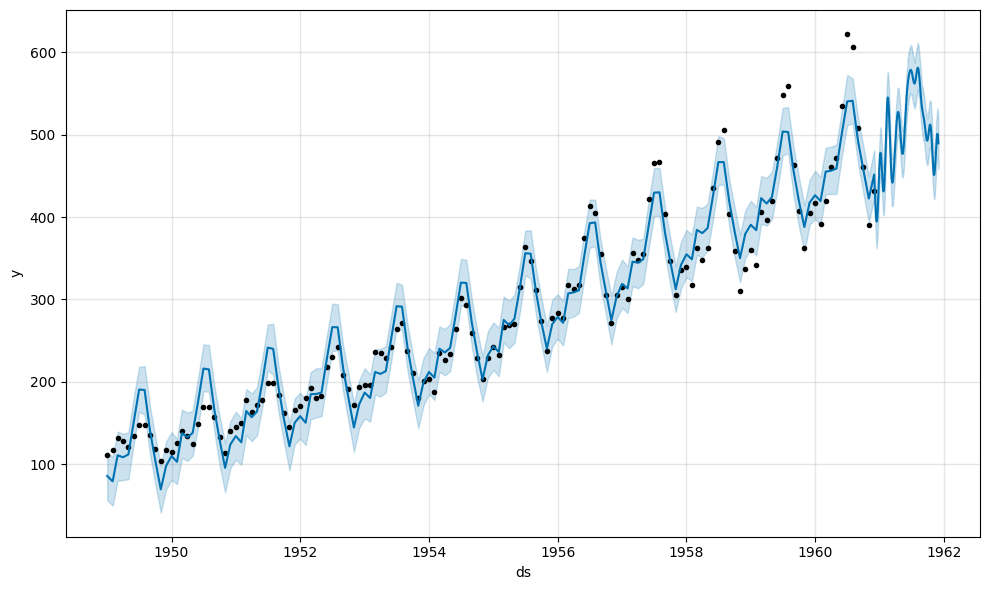

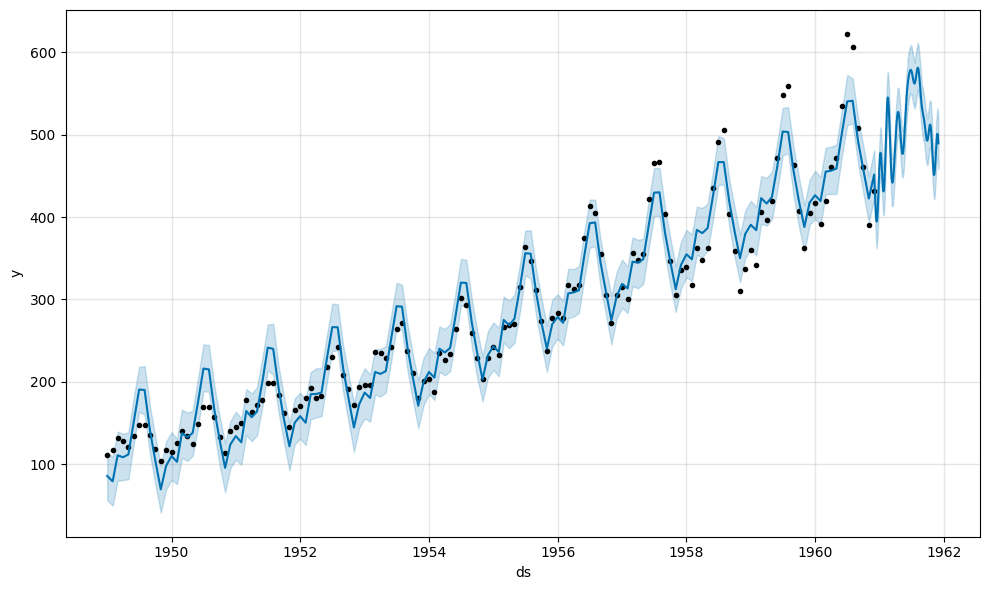

In [68]:
model.plot(pred)

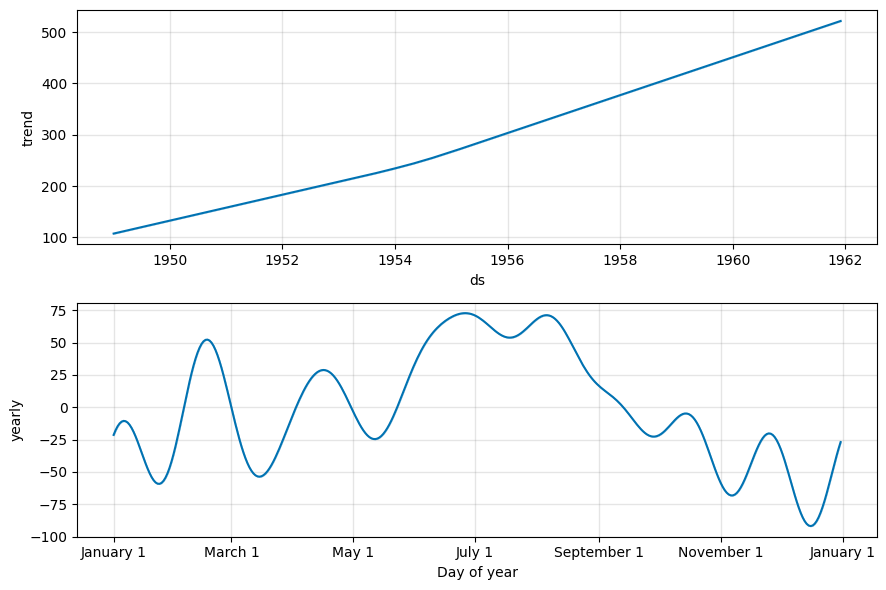

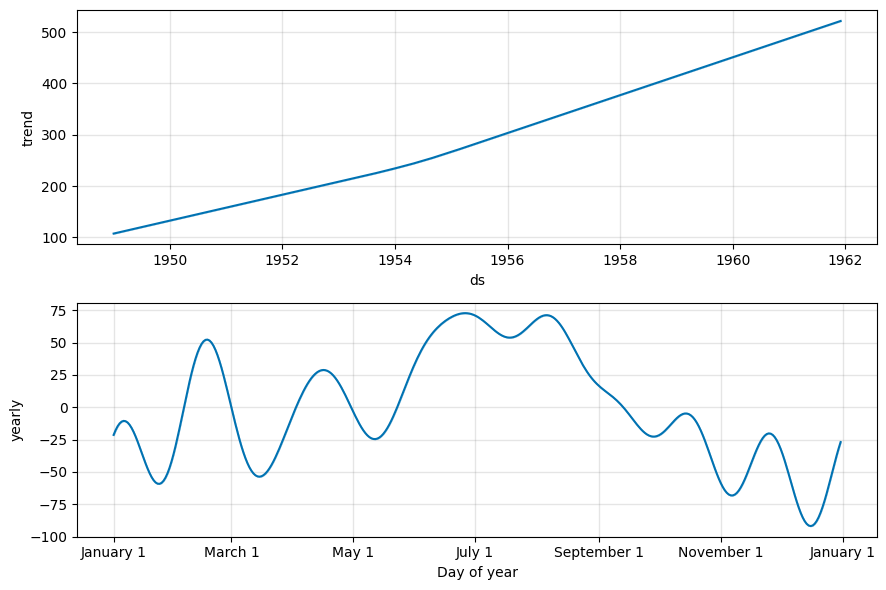

In [69]:
model.plot_components(pred)

In [70]:
# Now we have to do CROSS VALIDATION to check our model
# Lets assume we have data of 1960-1962
# cross validation will divide this dataset into 2 parts
# 1960-61 --> training dataset
# 1961-62 --> testing dataset

In [71]:
from prophet.diagnostics import cross_validation

In [72]:
df_cv=cross_validation(model,initial='730 days', period='180 days',horizon='365 days')

INFO:prophet:Making 19 forecasts with cutoffs between 1951-01-18 00:00:00 and 1959-12-02 00:00:00


  0%|          | 0/19 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.


In [73]:
df_cv.head()

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,1951-02-01,158.547167,158.295312,158.759396,150.0,1951-01-18
1,1951-03-01,171.930526,171.136130,172.597749,178.0,1951-01-18
2,1951-04-01,160.294098,158.620644,161.691577,163.0,1951-01-18
3,1951-05-01,146.088907,143.570447,148.292266,172.0,1951-01-18
4,1951-06-01,181.775447,178.117242,184.871009,178.0,1951-01-18


In [74]:
from prophet.diagnostics import performance_metrics
df_p=performance_metrics(df_cv)
df_p.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,40 days,1089.756319,33.011457,25.888132,0.078584,0.073831,0.079624,0.272727
1,42 days,1015.069514,31.860156,25.207098,0.076726,0.073831,0.077409,0.227273
2,46 days,909.811604,30.163083,24.621984,0.078579,0.078887,0.078319,0.181818
3,47 days,1044.412302,32.317368,26.737303,0.081350,0.085408,0.081498,0.181818
4,48 days,1034.021370,32.156203,26.194391,0.079480,0.085408,0.079693,0.227273
